In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from StockPickingModel import StockPickingModel

In [2]:
import pandas as pd
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

resp = requests.get(url, headers=headers, timeout=30)
resp.raise_for_status()

# Tabla de constituyentes
tabla = pd.read_html(StringIO(resp.text), attrs={"id": "constituents"})[0]

tickers = tabla["Symbol"].str.replace(".", "-", regex=False).tolist()
print(f"Número de tickers: {len(tickers)}")
print(tickers[:20])

Número de tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL']


[*********************100%***********************]  503 of 503 completed


Filas backtest: 264
Rendimiento total: 783.66%
       Fecha  Retorno_Neto     Curva
0 2021-01-06      0.045460  1.045460
1 2021-01-13      0.004011  1.049653
2 2021-01-20     -0.050911  0.996213
3 2021-01-27     -0.017965  0.978316
4 2021-02-03      0.103441  1.079514


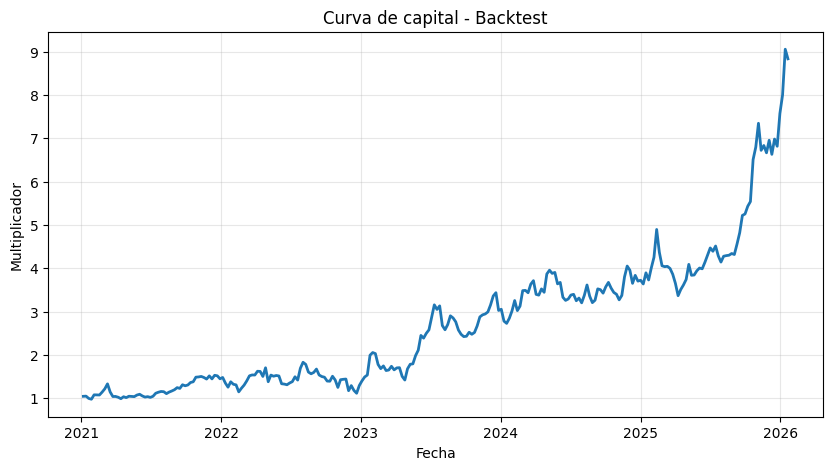

In [3]:
# tickers = [
#     "AAPL", "MSFT", "AMZN", "GS", "UNH", "V", "HD", "CRM", "CAT", "MA",
#     "JNJ", "PG", "WMT", "JPM", "AXP", "CVX", "DIS", "BA", "MCD", "MMM",
#     "INTC", "TRV", "IBM", "MRK", "NKE", "VZ", "HON", "CSCO", "AMGN", "KO"
# ]
spm = StockPickingModel(
    ticker_list=tickers,
    start_date="2019-01-01",
    end_date="2026-02-02",
    criterio=5,          # o "mediana"
    len_ventana=2,
    n_activos_obj=5,
    umbral_salida=8
)

resultados, rendimiento_total = spm.run_backtest(coste_operacion=0.001)

print(f"Filas backtest: {len(resultados)}")
print(f"Rendimiento total: {rendimiento_total:.2f}%")
print(resultados.head())

if len(resultados) > 0:
    plt.figure(figsize=(10,5))
    plt.plot(resultados["Fecha"], resultados["Curva"], lw=2)
    plt.title("Curva de capital - Backtest")
    plt.xlabel("Fecha")
    plt.ylabel("Multiplicador")
    plt.grid(alpha=0.3)
    plt.show()

=== Comparativa de métricas ===


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_11428\3752879658.py:83: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '783.66%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")
C:\Users\jpuerta\AppData\Local\Temp\ipykernel_11428\3752879658.py:83: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '102.30%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")


,ML + Buffer,EW Estática
Total Return,783.66%,102.30%
CAGR,53.60%,14.89%
Vol Anual,46.67%,15.84%
Sharpe,1.11,0.83
Sortino,1.82,1.15
Max Drawdown,-39.05%,-17.87%
Calmar,1.37,0.83


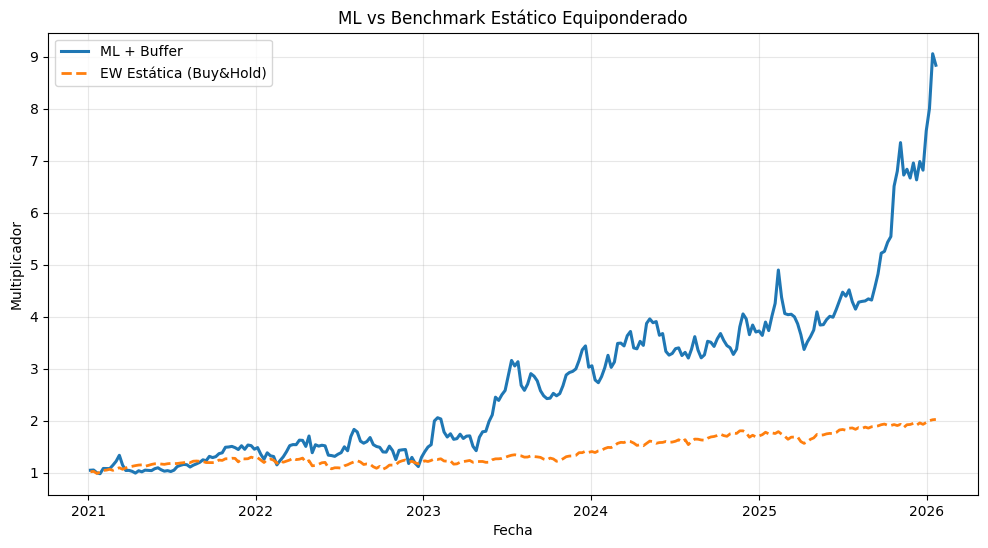

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Retornos estrategia ML
# =========================
ret_ml = resultados.set_index("Fecha")["Retorno_Neto"].copy()

# =========================================
# 2) Benchmark: estática equiponderada (EW)
#    (pesos iguales al inicio, luego drift)
# =========================================
r_next = spm.df.pivot_table(index="Fecha", columns="Ticker", values="Retorno_Next_Week")

# mismas fechas que la estrategia para comparar manzana con manzana
r_next = r_next.loc[ret_ml.index]

# pesos iniciales iguales en activos disponibles al inicio
primera_fecha = r_next.index[0]
activos_ini = r_next.loc[primera_fecha].dropna().index.tolist()
w = pd.Series(0.0, index=r_next.columns)
w.loc[activos_ini] = 1.0 / len(activos_ini)

ret_bh = []
for fecha in r_next.index:
    r = r_next.loc[fecha].fillna(0.0)     # si falta dato, asumimos 0 esa semana
    rp = float((w * r).sum())             # retorno cartera semana t
    ret_bh.append(rp)

    # actualizar pesos (buy & hold, sin rebalanceo)
    w = w * (1.0 + r)
    if w.sum() > 0:
        w = w / w.sum()

ret_bh = pd.Series(ret_bh, index=r_next.index, name="Retorno_BH")

# =====================
# 3) Métricas estándar
# =====================
def metrics(r, freq=52, rf_anual=0.02):
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    rf_w = (1 + rf_anual) ** (1 / freq) - 1
    curva = (1 + r).cumprod()

    total_return = curva.iloc[-1] - 1
    cagr = curva.iloc[-1] ** (freq / len(r)) - 1
    vol_anual = r.std(ddof=1) * np.sqrt(freq)

    exceso = r - rf_w
    sharpe = np.nan if vol_anual == 0 else (exceso.mean() * freq) / vol_anual

    downside = np.minimum(exceso, 0)
    downside_vol = np.sqrt((downside**2).mean()) * np.sqrt(freq)
    sortino = np.nan if downside_vol == 0 else (exceso.mean() * freq) / downside_vol

    dd = curva / curva.cummax() - 1
    max_dd = dd.min()
    calmar = np.nan if max_dd == 0 else cagr / abs(max_dd)

    return pd.Series({
        "Total Return": total_return,
        "CAGR": cagr,
        "Vol Anual": vol_anual,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar
    })

m_ml = metrics(ret_ml, freq=52, rf_anual=0.02)
m_bh = metrics(ret_bh, freq=52, rf_anual=0.02)

tabla = pd.concat([m_ml, m_bh], axis=1)
tabla.columns = ["ML + Buffer", "EW Estática"]

# Formato %
tabla_fmt = tabla.copy()
for c in ["Total Return", "CAGR", "Vol Anual", "Max Drawdown"]:
    tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")
for c in ["Sharpe", "Sortino", "Calmar"]:
    tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2f}")

print("=== Comparativa de métricas ===")
display(tabla_fmt)

# =====================
# 4) Curvas comparadas
# =====================
curva_ml = (1 + ret_ml).cumprod()
curva_bh = (1 + ret_bh).cumprod()

plt.figure(figsize=(12,6))
plt.plot(curva_ml.index, curva_ml.values, label="ML + Buffer", lw=2.2)
plt.plot(curva_bh.index, curva_bh.values, label="EW Estática (Buy&Hold)", lw=2, linestyle="--")
plt.title("ML vs Benchmark Estático Equiponderado")
plt.xlabel("Fecha")
plt.ylabel("Multiplicador")
plt.grid(alpha=0.3)
plt.legend()
plt.show()  

=== Rentabilidades anuales ===


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_11428\1676366001.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  anual_ml = (1 + ret_ml_y).resample("Y").prod() - 1
C:\Users\jpuerta\AppData\Local\Temp\ipykernel_11428\1676366001.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  anual_bh = (1 + ret_bh_y).resample("Y").prod() - 1


,ML + Buffer,EW Estática
Fecha,,
2021,44.98%,27.87%
2022,-10.68%,-7.01%
2023,133.82%,16.89%
2024,22.35%,21.39%
2025,104.43%,16.47%
2026,16.67%,2.95%


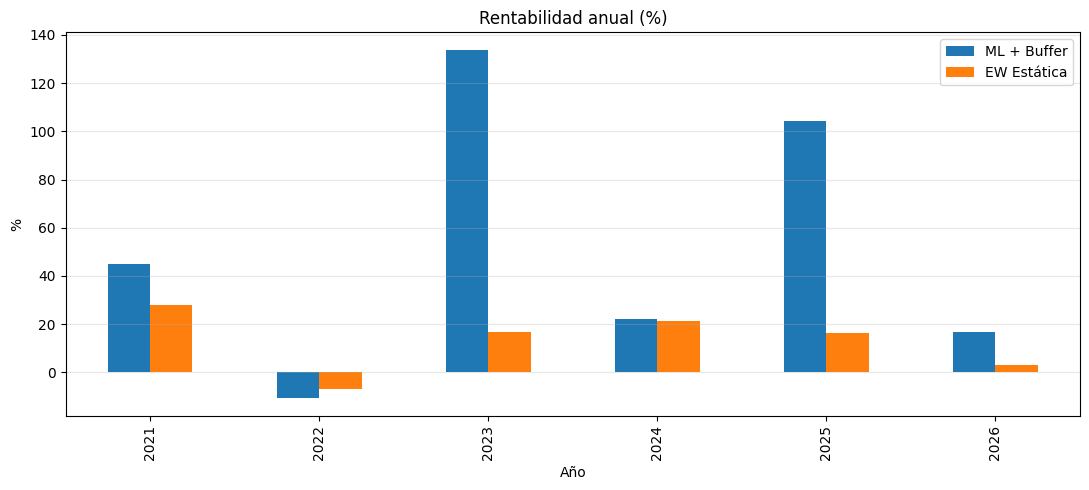

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar índices datetime
ret_ml_y = ret_ml.copy()
ret_bh_y = ret_bh.copy()
ret_ml_y.index = pd.to_datetime(ret_ml_y.index)
ret_bh_y.index = pd.to_datetime(ret_bh_y.index)

# Rentabilidad anual compuesta: (1+r1)*(1+r2)*...-1
anual_ml = (1 + ret_ml_y).resample("Y").prod() - 1
anual_bh = (1 + ret_bh_y).resample("Y").prod() - 1

# Tabla comparativa
tabla_anual = pd.concat([anual_ml, anual_bh], axis=1)
tabla_anual.columns = ["ML + Buffer", "EW Estática"]
tabla_anual.index = tabla_anual.index.year

print("=== Rentabilidades anuales ===")
display(tabla_anual.style.format("{:.2%}"))

# (Opcional) gráfico barras
ax = (tabla_anual * 100).plot(kind="bar", figsize=(11,5))
ax.set_title("Rentabilidad anual (%)")
ax.set_xlabel("Año")
ax.set_ylabel("%")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()